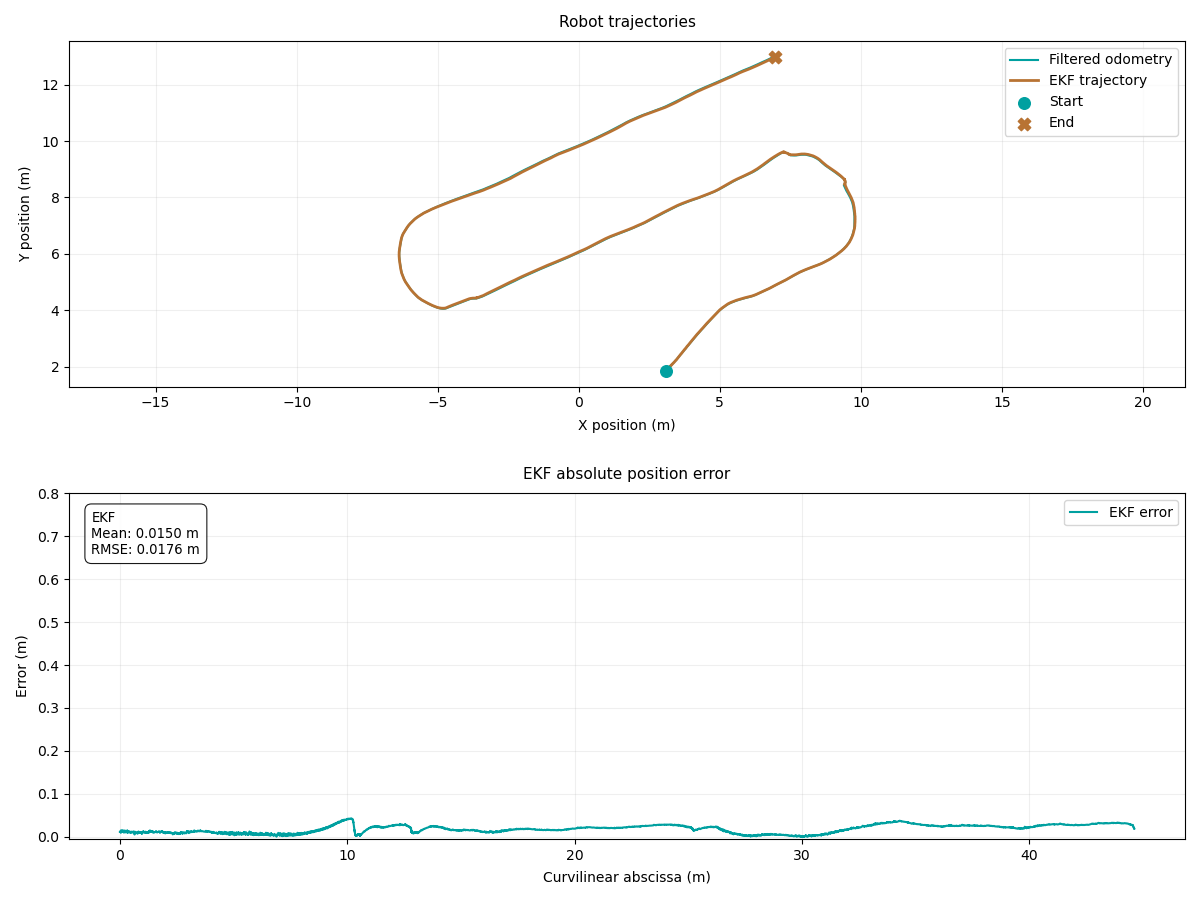

In [1]:
# %matplotlib inline
%matplotlib widget

import os
import math
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD AND PROCESS DATA (CLEAN & SIMPLE)
# ============================================================
transient_distance = 1.0  # meter

# Color palette from your reference figure layout
COLOR_CYAN = "#00A0A0"   # Clean matte cyan
COLOR_BROWN = "#B87333"  # Copper brown

# Load raw numpy tracking dumps
ekf = np.load("ekf_with_time.npy")
filt = np.load("filt_with_time.npy")

# Synchronize timestamps sorting
ekf = ekf[np.argsort(ekf[:, 0])]
filt = filt[np.argsort(filt[:, 0])]

# Keep common overlapping flight paths interval
valid_time = (ekf[:, 0] >= filt[0, 0]) & (ekf[:, 0] <= filt[-1, 0])
t_ekf = ekf[valid_time, 0]
x_ekf = ekf[valid_time, 1]
y_ekf = ekf[valid_time, 2]

# Synchronize odometry tracking data onto EKF timeline
x_filt_interp = np.interp(t_ekf, filt[:, 0], filt[:, 1])
y_filt_interp = np.interp(t_ekf, filt[:, 0], filt[:, 2])

# Compute continuous curvilinear abscissa path progression
ds = np.sqrt(np.diff(x_filt_interp)**2 + np.diff(y_filt_interp)**2)
s_ref = np.concatenate(([0.0], np.cumsum(ds)))

# Bypass early initial transient initialization settling distance
valid_dist = s_ref >= transient_distance
x_ekf, y_ekf = x_ekf[valid_dist], y_ekf[valid_dist]
x_filt_i, y_filt_i = x_filt_interp[valid_dist], y_filt_interp[valid_dist]
s_ref = s_ref[valid_dist] - s_ref[valid_dist][0]

# Compute true mathematical absolute Euclidean position tracking error
error_ekf_odom = np.sqrt((x_ekf - x_filt_i)**2 + (y_filt_i - y_ekf)**2)

# Calculate final error statistics logs
mean_err = np.mean(error_ekf_odom)
rmse_err = np.sqrt(np.mean(error_ekf_odom**2))

# Updated plain text statistics formatting for EKF
stats_text = (
    "EKF\n"
    f"Mean: {mean_err:.4f} m\n"
    f"RMSE: {rmse_err:.4f} m"
)

# ============================================================
# 2. PLOTTING WITH MATCHED DESIGN PROFILE
# ============================================================
os.makedirs("figure_dog", exist_ok=True)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))

# ---------------------------------
# Top Plot: Trajectories Matching Style
# ---------------------------------
ax1.plot(x_filt_i, y_filt_i, color=COLOR_CYAN, linewidth=1.5, label="Filtered odometry")
ax1.plot(x_ekf, y_ekf, color=COLOR_BROWN, linewidth=2.0, label="EKF trajectory")

# Start and end landmarks layout
ax1.scatter(x_filt_i[0], y_filt_i[0], color=COLOR_CYAN, marker="o", s=70, zorder=5, label="Start")
ax1.scatter(x_filt_i[-1], y_filt_i[-1], color=COLOR_BROWN, marker="X", s=80, zorder=5, label="End")

ax1.set_title("Robot trajectories", fontsize=11, pad=10)
ax1.set_xlabel("X position (m)", labelpad=6)
ax1.set_ylabel("Y position (m)", labelpad=6)
ax1.axis("equal")
ax1.grid(True, alpha=0.2)
ax1.legend(loc="upper right", frameon=True)

# ---------------------------------
# Bottom Plot: Clean Error Curve
# ---------------------------------
ax2.plot(s_ref, error_ekf_odom, color=COLOR_CYAN, linewidth=1.5, label="EKF error")

# --- CALIBRATED VERTICAL AXIS SCALE ---
# Set to 0.06 (6 centimeters) so the error curve is clearly visible and clean
ax2.set_ylim(-0.005, 0.80) 

ax2.set_title("EKF absolute position error", fontsize=11, pad=10)
ax2.set_xlabel("Curvilinear abscissa (m)", labelpad=6)
ax2.set_ylabel("Error (m)", labelpad=6)
ax2.grid(True, alpha=0.2)
ax2.legend(loc="upper right", frameon=True)

# Overlay dynamic text summary block on the left side WITH border box enabled
ax2.text(
    0.02, 0.95, stats_text, transform=ax2.transAxes,
    verticalalignment="top", horizontalalignment="left", 
    fontsize=9.5, color="black",
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": "white",
        "edgecolor": "black",
        "linewidth": 0.8,
        "alpha": 0.9
    }
)

plt.tight_layout(h_pad=2.5)
plt.savefig("figure_dog/ekf_error_curvilinear_abscissa.pdf", bbox_inches="tight", pad_inches=0.15)
plt.show()



Graphique sauvegardé avec succès dans : figure_dog/ekf_dual_error_comparison.pdf


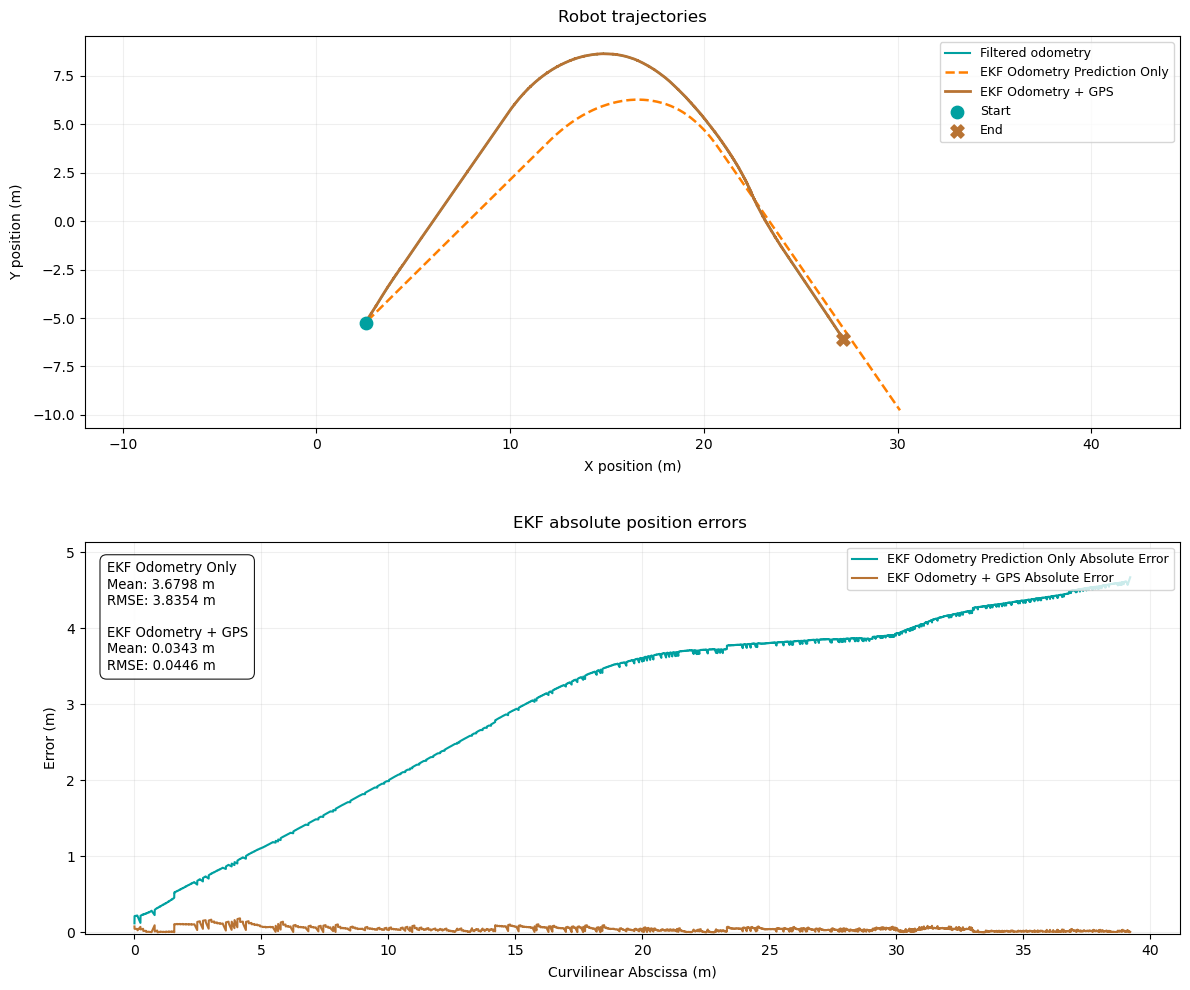

In [1]:
#!/usr/bin/env python3
#code for a dual comparison between EKF +odom and EKF + odom (prediction) + GPS (update)
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. CHARGEMENT ET PRÉPARATION DES DONNÉES
# ============================================================
transient_distance = 1.0  # Distance de transition initiale (mètres)

# Palette de couleurs du profil graphique de référence
COLOR_CYAN = "#00A0A0"    # Cyan mat propre pour la référence
COLOR_BROWN = "#B87333"   # Brun cuivre pour l'EKF complet
COLOR_PURPLE = "#FF7F00"  # or pour l'EKF Odométrie seule

# Chargement des fichiers extraits de votre rosbag
# Aligné avec les fichiers sauvegardés par votre script d'extraction
try:
    odom_data = np.load("ekf_odom_with_time.npy")
    odom_gps_data = np.load("ekf_odom_gps_with_time.npy")
    filt_data = np.load("filt_with_time.npy")
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"Erreur de chargement : assurez-vous d'avoir exécuté le script "
        f"d'extraction au préalable dans ce répertoire. Détail : {e}"
    )

# Synchronisation et tri chronologique par sécurité
odom_data = odom_data[np.argsort(odom_data[:, 0])]
odom_gps_data = odom_gps_data[np.argsort(odom_gps_data[:, 0])]
filt_data = filt_data[np.argsort(filt_data[:, 0])]

# Détermination de l'intervalle de temps partagé par toutes les sources
common_start = max(odom_data[0, 0], odom_gps_data[0, 0], filt_data[0, 0])
common_end = min(odom_data[-1, 0], odom_gps_data[-1, 0], filt_data[-1, 0])

# Masques pour filtrer uniquement la zone temporelle commune
valid_odom = (odom_data[:, 0] >= common_start) & (odom_data[:, 0] <= common_end)
valid_gps = (odom_gps_data[:, 0] >= common_start) & (odom_gps_data[:, 0] <= common_end)

t_odom = odom_data[valid_odom, 0]
x_odom = odom_data[valid_odom, 1]
y_odom = odom_data[valid_odom, 2]

t_gps = odom_gps_data[valid_gps, 0]
x_gps = odom_gps_data[valid_gps, 1]
y_gps = odom_gps_data[valid_gps, 2]

# Synchronisation (interpolation) des données sur une ligne temporelle commune (celle du GPS)
x_filt_interp = np.interp(t_gps, filt_data[:, 0], filt_data[:, 1])
y_filt_interp = np.interp(t_gps, filt_data[:, 0], filt_data[:, 2])

x_odom_interp = np.interp(t_gps, t_odom, x_odom)
y_odom_interp = np.interp(t_gps, t_odom, y_odom)

# Calcul de l'abscisse curviligne le long de la trajectoire de référence (filt)
ds = np.sqrt(np.diff(x_filt_interp)**2 + np.diff(y_filt_interp)**2)
s_ref = np.concatenate(([0.0], np.cumsum(ds)))

# Retrait du régime transitoire initial basé sur la distance définie
valid_dist = s_ref >= transient_distance

x_filt_final = x_filt_interp[valid_dist]
y_filt_final = y_filt_interp[valid_dist]

x_gps_final = x_gps[valid_dist]
y_gps_final = y_gps[valid_dist]

x_odom_final = x_odom_interp[valid_dist]
y_odom_final = y_odom_interp[valid_dist]

s_ref_final = s_ref[valid_dist] - s_ref[valid_dist][0]

# ============================================================
# 2. CALCUL DES ERREURS ABSOLUES ET STATISTIQUES
# ============================================================
# Erreur 1 : EKF Odométrie seule par rapport à la référence filtrée
error_odom_only = np.sqrt((x_odom_final - x_filt_final)**2 + (y_odom_final - y_filt_final)**2)

# Erreur 2 : EKF Odométrie + GPS par rapport à la référence filtrée
error_odom_gps = np.sqrt((x_gps_final - x_filt_final)**2 + (y_filt_final - y_gps_final)**2)

# Calcul des indicateurs statistiques (Moyenne & RMSE)
mean_err_odom = np.mean(error_odom_only)
rmse_err_odom = np.sqrt(np.mean(error_odom_only**2))

mean_err_gps = np.mean(error_odom_gps)
rmse_err_gps = np.sqrt(np.mean(error_odom_gps**2))

# Mise en forme du bloc de texte statistique unifié
stats_text = (
    "EKF Odometry Only\n"
    f"Mean: {mean_err_odom:.4f} m\n"
    f"RMSE: {rmse_err_odom:.4f} m\n\n"
    "EKF Odometry + GPS\n"
    f"Mean: {mean_err_gps:.4f} m\n"
    f"RMSE: {rmse_err_gps:.4f} m"
)

# ============================================================
# 3. GÉNÉRATION DES GRAPHIQUES (MATPLOTLIB)
# ============================================================
os.makedirs("figure_dog", exist_ok=True)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# --------------------------------------------------------
# Graphique Supérieur : Comparaison Spatiale des Trajectoires
# --------------------------------------------------------
# Tracé de la référence
ax1.plot(x_filt_final, y_filt_final, color=COLOR_CYAN, linewidth=1.5, 
         label="Filtered odometry ")

# Tracé de l'EKF sans GPS (Prédiction seule)
ax1.plot(x_odom_final, y_odom_final, color=COLOR_PURPLE, linewidth=1.8, linestyle="--",
         label="EKF Odometry Prediction Only")

# Tracé de l'EKF complet (Avec correction GPS)
ax1.plot(x_gps_final, y_gps_final, color=COLOR_BROWN, linewidth=2.0, 
         label="EKF Odometry + GPS")

# Marquage des points de départ et d'arrivée
ax1.scatter(x_filt_final[0], y_filt_final[0], color=COLOR_CYAN, marker="o", s=80, zorder=5, label="Start")
ax1.scatter(x_filt_final[-1], y_filt_final[-1], color=COLOR_BROWN, marker="X", s=90, zorder=5, label="End")

ax1.set_title("Robot trajectories", fontsize=12, pad=10)
ax1.set_xlabel("X position (m)", labelpad=6)
ax1.set_ylabel("Y position (m)", labelpad=6)
ax1.axis("equal")
ax1.grid(True, alpha=0.2)
ax1.legend(loc="upper right", frameon=True, fontsize=9)

# --------------------------------------------------------
# Graphique Inférieur : Évolution Temporelle des Erreurs
# --------------------------------------------------------
# Courbe d'erreur EKF Odométrie seule
ax2.plot(s_ref_final, error_odom_only, color=COLOR_CYAN, linewidth=1.5, 
         label="EKF Odometry Prediction Only Absolute Error")

# Courbe d'erreur EKF Complet (Odom + GPS)
ax2.plot(s_ref_final, error_odom_gps, color=COLOR_BROWN, linewidth=1.5, 
         label="EKF Odometry + GPS Absolute Error")

# Configuration de l'axe vertical pour englober la dérive odométrique
max_error_observed = max(np.max(error_odom_only), np.max(error_odom_gps))
ax2.set_ylim(-0.02, max_error_observed * 1.1)

ax2.set_title("EKF absolute position errors ", fontsize=12, pad=10)
ax2.set_xlabel("Curvilinear Abscissa (m)", labelpad=6)
ax2.set_ylabel("Error (m)", labelpad=6)
ax2.grid(True, alpha=0.2)
ax2.legend(loc="upper right", frameon=True, fontsize=9)

# Incrustation de l'encadré contenant les métriques statistiques globales
ax2.text(
    0.02, 0.95, stats_text, transform=ax2.transAxes,
    verticalalignment="top", horizontalalignment="left", 
    fontsize=9.5, color="black",
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": "white",
        "edgecolor": "black",
        "linewidth": 0.8,
        "alpha": 0.9
    }
)

# Ajustement de la géométrie et sauvegarde au format PDF vectoriel
plt.tight_layout(h_pad=3.0)
output_path = "figure_dog/ekf_dual_error_comparison.pdf"
plt.savefig(output_path, bbox_inches="tight", pad_inches=0.15)
print(f"\nGraphique sauvegardé avec succès dans : {output_path}")
plt.show()


Graphique nettoyé et sauvegardé dans : figure_dog/ekf_decomposed_errors_curvilinear_abscissa.pdf


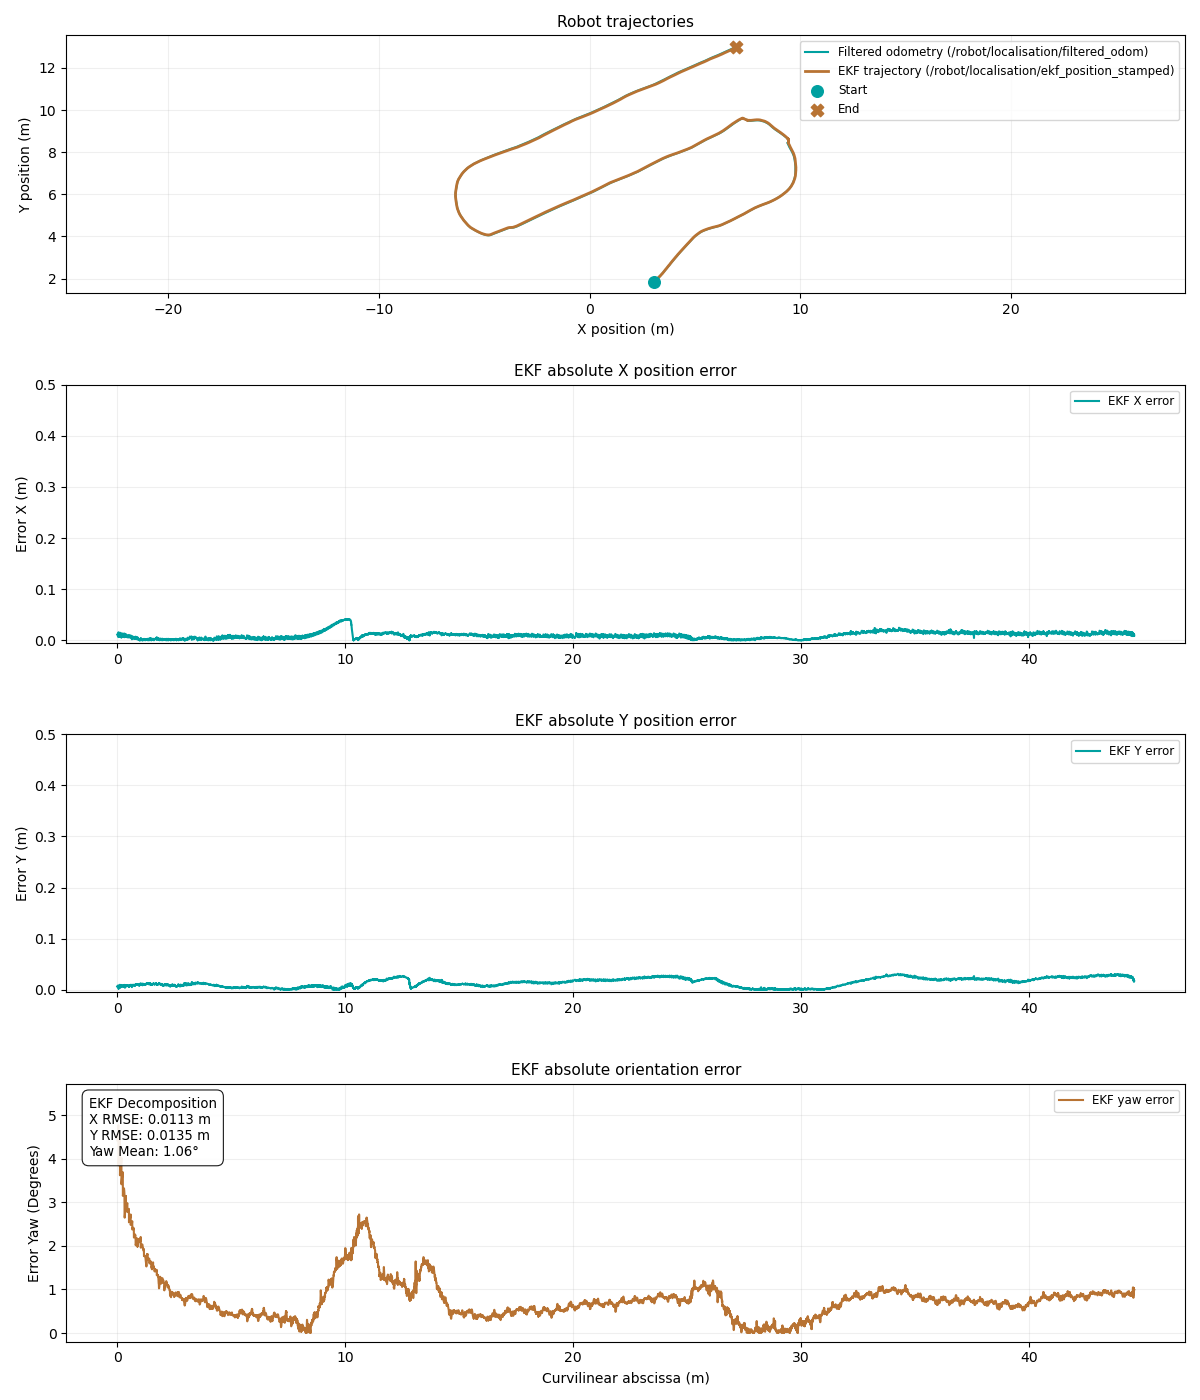

In [1]:
# %matplotlib inline
%matplotlib widget

import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD AND PROCESS DATA (CLEAN & SIMPLE)
# ============================================================
transient_distance = 1.0  # meter

# Color palette from your reference figure layout
COLOR_CYAN = "#00A0A0"   # Clean matte cyan
COLOR_BROWN = "#B87333"  # Copper brown
DARK_BLUE = "#006F6F"

# Load raw numpy tracking dumps [t, x, y, yaw]
ekf = np.load("ekf_with_time.npy")
filt = np.load("filt_with_time.npy")

if ekf.size == 0:
    raise ValueError("ekf_with_time.npy is empty.")

if filt.size == 0:
    raise ValueError("filt_with_time.npy is empty.")

# Synchronize timestamps sorting
ekf = ekf[np.argsort(ekf[:, 0])]
filt = filt[np.argsort(filt[:, 0])]

# Keep common overlapping flight paths interval
valid_time = (ekf[:, 0] >= filt[0, 0]) & (ekf[:, 0] <= filt[-1, 0])
t_ekf = ekf[valid_time, 0]
x_ekf = ekf[valid_time, 1]
y_ekf = ekf[valid_time, 2]
yaw_ekf = ekf[valid_time, 3]

# Extract raw reference tracking variables
t_filt = filt[:, 0]
x_filt = filt[:, 1]
y_filt = filt[:, 2]
yaw_filt = filt[:, 3]

# --------------------------------------------------------
# TIME SYNCHRONIZATION WITH ANGLE UNWRAP (ANTI-SPIKE)
# --------------------------------------------------------
# Linear interpolation for spatial coordinates
x_filt_interp = np.interp(t_ekf, t_filt, x_filt)
y_filt_interp = np.interp(t_ekf, t_filt, y_filt)

# UNWRAP CORRECTION : Prevents np.interp from averaging between +179° and -179° (which yields 0°)
yaw_filt_unwrapped = np.unwrap(yaw_filt)
yaw_filt_interp_unwrapped = np.interp(t_ekf, t_filt, yaw_filt_unwrapped)

# Rewrap the interpolated reference angles smoothly between [-pi, pi]
yaw_filt_interp = np.arctan2(np.sin(yaw_filt_interp_unwrapped), np.cos(yaw_filt_interp_unwrapped))

# Compute continuous curvilinear abscissa path progression
ds = np.sqrt(np.diff(x_filt_interp)**2 + np.diff(y_filt_interp)**2)
s_ref = np.concatenate(([0.0], np.cumsum(ds)))

# Bypass early initial transient initialization settling distance
valid_dist = s_ref >= transient_distance
x_ekf, y_ekf, yaw_ekf = x_ekf[valid_dist], y_ekf[valid_dist], yaw_ekf[valid_dist]
x_filt_i, y_filt_i, yaw_filt_i = x_filt_interp[valid_dist], y_filt_interp[valid_dist], yaw_filt_interp[valid_dist]
s_ref = s_ref[valid_dist] - s_ref[valid_dist][0]

# --------------------------------------------------------
# ERROR DECOMPOSITION METRICS
# --------------------------------------------------------
# Compute mathematical absolute tracking error for each axis independently
error_x = np.abs(x_ekf - x_filt_i)
error_y = np.abs(y_ekf - y_filt_i)

# Compute true normalized angular difference between [-pi, pi]
raw_angle_diff = np.arctan2(np.sin(yaw_ekf - yaw_filt_i), np.cos(yaw_ekf - yaw_filt_i))
error_yaw = np.abs(raw_angle_diff) * (180.0 / np.pi)

# Calculate final error statistics logs per axis
rmse_x = np.sqrt(np.mean(error_x**2))
rmse_y = np.sqrt(np.mean(error_y**2))
mean_err_yaw = np.mean(error_yaw)

# Plain text statistics formatting for EKF layout block
stats_text = (
    "EKF Decomposition\n"
    f"X RMSE: {rmse_x:.4f} m\n"
    f"Y RMSE: {rmse_y:.4f} m\n"
    f"Yaw Mean: {mean_err_yaw:.2f}°"
)

# ============================================================
# 2. PLOTTING WITH MATCHED DESIGN PROFILE
# ============================================================
os.makedirs("figure_dog", exist_ok=True)
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 14))

# ---------------------------------
# Plot 1: Trajectories Matching Style
# ---------------------------------
ax1.plot(x_filt_i, y_filt_i, color=COLOR_CYAN, linewidth=1.5, label="Filtered odometry (/robot/localisation/filtered_odom)")
ax1.plot(x_ekf, y_ekf, color=COLOR_BROWN, linewidth=2.0, label="EKF trajectory (/robot/localisation/ekf_position_stamped)")

# Start and end landmarks layout
ax1.scatter(x_filt_i[0], y_filt_i[0], color=COLOR_CYAN, marker="o", s=70, zorder=5, label="Start")
ax1.scatter(x_filt_i[-1], y_filt_i[-1], color=COLOR_BROWN, marker="X", s=80, zorder=5, label="End")

ax1.set_title("Robot trajectories", fontsize=11, pad=6)
ax1.set_xlabel("X position (m)", labelpad=4)
ax1.set_ylabel("Y position (m)", labelpad=4)
ax1.axis("equal")
ax1.grid(True, alpha=0.2)
ax1.legend(loc="upper right", frameon=True, fontsize=8.5)

# ---------------------------------
# Plot 2: Absolute X Error Curve
# ---------------------------------
ax2.plot(s_ref, error_x, color=COLOR_CYAN, linewidth=1.5, label="EKF X error")
ax2.set_ylim(-0.005, max(np.max(error_x) * 1.1, 0.50)) 

ax2.set_title("EKF absolute X position error", fontsize=11, pad=6)
ax2.set_ylabel("Error X (m)", labelpad=4)
ax2.grid(True, alpha=0.2)
ax2.legend(loc="upper right", frameon=True, fontsize=8.5)

# ---------------------------------
# Plot 3: Absolute Y Error Curve
# ---------------------------------
ax3.plot(s_ref, error_y, color=COLOR_CYAN, linewidth=1.5, label="EKF Y error")
ax3.set_ylim(-0.005, max(np.max(error_y) * 1.1, 0.50)) 

ax3.set_title("EKF absolute Y position error", fontsize=11, pad=6)
ax3.set_ylabel("Error Y (m)", labelpad=4)
ax3.grid(True, alpha=0.2)
ax3.legend(loc="upper right", frameon=True, fontsize=8.5)

# ---------------------------------
# Plot 4: Clean Orientation Error Curve (Spike-free)
# ---------------------------------
ax4.plot(s_ref, error_yaw, color=COLOR_BROWN, linewidth=1.5, label="EKF yaw error")

# Dynamic axis scale adapted to the real clean noise level
ax4.set_ylim(-0.2, max(np.max(error_yaw) * 1.2, 5.0))

ax4.set_title("EKF absolute orientation error", fontsize=11, pad=6)
ax4.set_xlabel("Curvilinear abscissa (m)", labelpad=4)
ax4.set_ylabel("Error Yaw (Degrees)", labelpad=4)
ax4.grid(True, alpha=0.2)
ax4.legend(loc="upper right", frameon=True, fontsize=8.5)

# Overlay dynamic text summary block on the left side WITH border box enabled
ax4.text(
    0.02, 0.95, stats_text, transform=ax4.transAxes,
    verticalalignment="top", horizontalalignment="left", 
    fontsize=9.5, color="black",
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": "white",
        "edgecolor": "black",
        "linewidth": 0.8,
        "alpha": 0.9
    }
)

plt.tight_layout(h_pad=2.0)
plt.savefig("figure_dog/ekf_decomposed_errors_curvilinear_abscissa.pdf", bbox_inches="tight", pad_inches=0.15)
print("Graphique nettoyé et sauvegardé dans : figure_dog/ekf_decomposed_errors_curvilinear_abscissa.pdf")
plt.show()


In [2]:
%matplotlib widget

import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD AND PROCESS DATA
# ============================================================

transient_distance = 1.0  # meter

COLOR_CYAN = "#00A0A0"
COLOR_BROWN = "#B87333"

# Files extracted from the EKF 3D bag
ekf = np.load("ekf3d_with_time.npy")
filt = np.load("filt3d_with_time.npy")

# Sort by timestamp
ekf = ekf[np.argsort(ekf[:, 0])]
filt = filt[np.argsort(filt[:, 0])]

# Keep only the common time interval
valid_time = (
    (ekf[:, 0] >= filt[0, 0]) &
    (ekf[:, 0] <= filt[-1, 0])
)

t_ekf = ekf[valid_time, 0]
x_ekf = ekf[valid_time, 1]
y_ekf = ekf[valid_time, 2]

# Interpolate filtered odometry on the EKF 3D timestamps
x_filt_interp = np.interp(
    t_ekf,
    filt[:, 0],
    filt[:, 1]
)

y_filt_interp = np.interp(
    t_ekf,
    filt[:, 0],
    filt[:, 2]
)

# Curvilinear abscissa from filtered odometry
ds = np.sqrt(
    np.diff(x_filt_interp)**2 +
    np.diff(y_filt_interp)**2
)

s_ref = np.concatenate(
    ([0.0], np.cumsum(ds))
)

# Remove initial transient
valid_dist = s_ref >= transient_distance

x_ekf = x_ekf[valid_dist]
y_ekf = y_ekf[valid_dist]

x_filt_i = x_filt_interp[valid_dist]
y_filt_i = y_filt_interp[valid_dist]

s_ref = (
    s_ref[valid_dist]
    - s_ref[valid_dist][0]
)

# Euclidean position discrepancy
error_ekf_odom = np.sqrt(
    (x_ekf - x_filt_i)**2 +
    (y_ekf - y_filt_i)**2
)

# Statistics
mean_err = np.mean(error_ekf_odom)

rmse_err = np.sqrt(
    np.mean(error_ekf_odom**2)
)

max_err = np.max(error_ekf_odom)

std_err = np.std(error_ekf_odom)

print("\n===== EKF 3D RESULTS =====")
print(f"Mean error : {mean_err:.4f} m")
print(f"RMSE       : {rmse_err:.4f} m")
print(f"Max error  : {max_err:.4f} m")
print(f"Std error  : {std_err:.4f} m")


stats_text = (
    "EKF \n"
    f"Mean: {mean_err:.4f} m\n"
    f"RMSE: {rmse_err:.4f} m"
)

# ============================================================
# 2. PLOTTING
# ============================================================

os.makedirs(
    "figure_dog",
    exist_ok=True
)

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(12, 9)
)

# ------------------------------------------------------------
# Top plot: trajectories
# ------------------------------------------------------------

ax1.plot(x_filt_i,y_filt_i,color=COLOR_CYAN,linewidth=1.5,label="Filtered odometry")
ax1.plot(x_ekf,y_ekf,color=COLOR_BROWN,linewidth=2.0,label="EKF trajectory")

# Start point
ax1.scatter(x_filt_i[0],y_filt_i[0],color=COLOR_CYAN,marker="o",s=70,zorder=5,label="Start")
# End point
ax1.scatter(x_filt_i[-1],y_filt_i[-1],color=COLOR_BROWN,marker="X",s=80,zorder=5,label="End")
ax1.set_title("Robot trajectories",fontsize=11,pad=10)
ax1.set_xlabel("X position (m)",
    labelpad=6
)
ax1.set_ylabel(
    "Y position (m)",
    labelpad=6
)

ax1.axis("equal")

ax1.grid(
    True,
    alpha=0.2
)

ax1.legend(
    loc="upper right",
    frameon=True
)

# ------------------------------------------------------------
# Bottom plot: EKF 3D position discrepancy
# ------------------------------------------------------------

ax2.plot(
    s_ref,
    error_ekf_odom,
    color=COLOR_CYAN,
    linewidth=1.5,
    label="EKF  error"
)

ax2.set_title(
    "EKF  absolute position error",
    fontsize=11,
    pad=10
)

ax2.set_xlabel(
    "Curvilinear abscissa (m)",
    labelpad=6
)

ax2.set_ylabel(
    "Error (m)",
    labelpad=6
)
ax2.set_ylim(0.0, 0.8)
ax2.grid(
    True,
    alpha=0.2
)

ax2.legend(
    loc="upper right",
    frameon=True
)

# Statistics box
ax2.text(
    0.02,
    0.95,
    stats_text,
    transform=ax2.transAxes,
    verticalalignment="top",
    horizontalalignment="left",
    fontsize=9.5,
    color="black",
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": "white",
        "edgecolor": "black",
        "linewidth": 0.8,
        "alpha": 0.9
    }
)

plt.tight_layout(
    h_pad=2.5
)

# Save without overwriting the 5D figure
plt.savefig(
    "figure_dog/ekf3d_error_curvilinear_abscissa.pdf",
    bbox_inches="tight",
    pad_inches=0.15
)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'ekf3d_with_time.npy'